# Phase 4 — vLLM vs Hugging Face baseline

How much does an optimized serving system improve TTFT, throughput, and the (context × batch) feasibility frontier?

Same workloads as Phase 1 (single-request context sweep) and Phase 2 (batched sweep), run on **vLLM** with PagedAttention.

**Scope:**
- Model: `meta-llama/Meta-Llama-3.1-8B-Instruct` only — isolates the backend variable. (Phase 1 varies the model; this notebook varies the backend.)
- Hardware: A100.
- Sweeps: ctx 8k/16k/32k/64k at batch 1 (mirrors Phase 1) plus ctx 8k & 32k at batch 1/2/4/8/16 (mirrors Phase 2).

In [ ]:
import os

REPO_URL = "https://github.com/sonavk2/LLM_Inference.git"
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

%cd {REPO_NAME}
!git pull

Cloning into 'LLM_Inference'...
remote: Enumerating objects: 201, done.
remote: Counting objects: 100% (201/201), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 201 (delta 97), reused 94 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (201/201), 1.61 MiB | 8.73 MiB/s, done.
Resolving deltas: 100% (97/97), done.
/content/LLM_Inference/LLM_Inference/LLM_Inference/LLM_Inference
Already up to date.


In [ ]:
!pip install -q -r requirements.txt
!pip install -q -r requirements-vllm.txt

In [ ]:
from huggingface_hub import login
login()

In [ ]:
!python3 scripts/run_vllm_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 1024 \
  --max-new-tokens 32 \
  --max-model-len 2048 \
  --results-path results/phase4_smoke.jsonl

Loading meta-llama/Meta-Llama-3.1-8B-Instruct on vLLM (dtype=bfloat16, max_model_len=2048, gpu_mem_util=0.9) ...
INFO 04-30 06:46:20 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 2048, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.9, 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct'}
INFO 04-30 06:46:24 [model.py:555] Resolved architecture: LlamaForCausalLM
INFO 04-30 06:46:24 [model.py:1680] Using max model len 2048
INFO 04-30 06:46:24 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-30 06:46:24 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 04-30 06:46:24 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])
WARNING 04-30 06:46:31 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for 

In [ ]:
import json
row = json.loads(open('results/phase4_smoke.jsonl').readlines()[-1])
assert row['success'], f"Smoke test failed: {row['error']}"
assert row['ttft_seconds'] is not None, "vLLM RequestOutput.metrics did not populate TTFT — check vLLM version / disable_log_stats"
print(f"smoke ok — ttft={row['ttft_seconds']:.3f}s total={row['total_latency_seconds']:.3f}s tps={row['tokens_per_second']:.2f}")

smoke ok — ttft=0.119s total=0.467s tps=68.53


## Sweep A — single-request context length (mirrors Phase 1)

Same dimensions as `phase1_llama31_a100.jsonl`


In [ ]:
# 4. Context sweep on vLLM, batch=1, ctx 8k/16k/32k/64k.
!python3 scripts/run_vllm_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --max-model-len 65664 \
  --results-path results/phase4_llama31_a100.jsonl


Loading meta-llama/Meta-Llama-3.1-8B-Instruct on vLLM (dtype=bfloat16, max_model_len=65664, gpu_mem_util=0.9) ...
INFO 04-30 06:47:39 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 65664, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.9, 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct'}
INFO 04-30 06:47:43 [model.py:555] Resolved architecture: LlamaForCausalLM
INFO 04-30 06:47:43 [model.py:1680] Using max model len 65664
INFO 04-30 06:47:43 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-30 06:47:43 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 04-30 06:47:43 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])
WARNING 04-30 06:47:49 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing f

## Sweep B — batched inference (mirrors Phase 2)

Same `(context, batch)` grid as Phase 2 — the cells that OOM'd on HF are the ones where vLLM should not


In [ ]:
# 5. Batch sweep on vLLM. Appends to the same JSONL as the context sweep.
!python3 scripts/run_vllm_batch_experiment.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 32768 \
  --batch-sizes 1 2 4 8 16 \
  --max-new-tokens 64 \
  --max-model-len 33024 \
  --results-path results/phase4_llama31_a100.jsonl


Loading meta-llama/Meta-Llama-3.1-8B-Instruct on vLLM (dtype=bfloat16, max_model_len=33024, gpu_mem_util=0.9) ...
INFO 04-30 06:50:01 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 33024, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.9, 'model': 'meta-llama/Meta-Llama-3.1-8B-Instruct'}
INFO 04-30 06:50:04 [model.py:555] Resolved architecture: LlamaForCausalLM
INFO 04-30 06:50:04 [model.py:1680] Using max model len 33024
INFO 04-30 06:50:04 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-30 06:50:04 [vllm.py:840] Asynchronous scheduling is enabled.
INFO 04-30 06:50:04 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])
WARNING 04-30 06:50:11 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing f

## Comparison plots

Loads:
- `results/phase1_llama31_a100.jsonl` — HF baseline, single-request context sweep
- `results/phase2_llama31_a100.jsonl` — HF baseline, batched sweep
- `results/phase4_llama31_a100.jsonl` — vLLM, both sweeps

Three figures:
1. **TTFT vs context length** (single-request). Direct apples-to-apples.
2. **Latency-vs-throughput Pareto** with both backends overlaid. **The headline plot.**
3. **Frontier annotation** — text+plot combination showing where HF OOM'd vs where vLLM degraded.

Peak GPU memory is intentionally not plotted (vLLM pre-allocates a pool, so the comparison would mislead).


In [ ]:
import json, glob
from pathlib import Path
import pandas as pd

def load_files(pattern, backend_label):
    rows = []
    for path in sorted(glob.glob(pattern)):
        for line in open(path):
            r = json.loads(line)
            r['_source'] = Path(path).name
            r['_backend'] = backend_label
            rows.append(r)
    return rows

hf_p1 = load_files('results/phase1_llama31_*.jsonl', 'HF (baseline)')
hf_p2 = load_files('results/phase2_llama31_*.jsonl', 'HF (baseline)')
vllm  = load_files('results/phase4_llama31_*.jsonl', 'vLLM')

df = pd.DataFrame(hf_p1 + hf_p2 + vllm)
df['per_request_tps'] = df.apply(
    lambda r: (r['tokens_per_second'] / r['batch_size']) if r['success'] else None, axis=1
)
print(f'loaded {len(df)} rows: HF={len(hf_p1)+len(hf_p2)}, vLLM={len(vllm)}')
print(df[['_backend', 'context_length', 'batch_size', 'success',
          'ttft_seconds', 'total_latency_seconds', 'tokens_per_second']]
      .sort_values(['_backend', 'context_length', 'batch_size'])
      .to_string(index=False))


loaded 38 rows: HF=24, vLLM=14
     _backend  context_length  batch_size  success  ttft_seconds  total_latency_seconds  tokens_per_second
HF (baseline)            8192           1     True      1.098092               5.372323          23.825820
HF (baseline)            8192           1     True      1.129634               3.379984          18.935004
HF (baseline)            8192           1     True      1.119816               3.347555          19.118430
HF (baseline)            8192           2     True      1.302515               3.527705          36.284215
HF (baseline)            8192           2     True      1.302220               3.544544          36.111839
HF (baseline)            8192           4     True      2.578645               4.818181          53.132081
HF (baseline)            8192           4     True      2.580507               4.838670          52.907106
HF (baseline)            8192           8     True      5.158125               7.642964          66.989719
HF (ba

saved results/plots/phase4_single_request.png


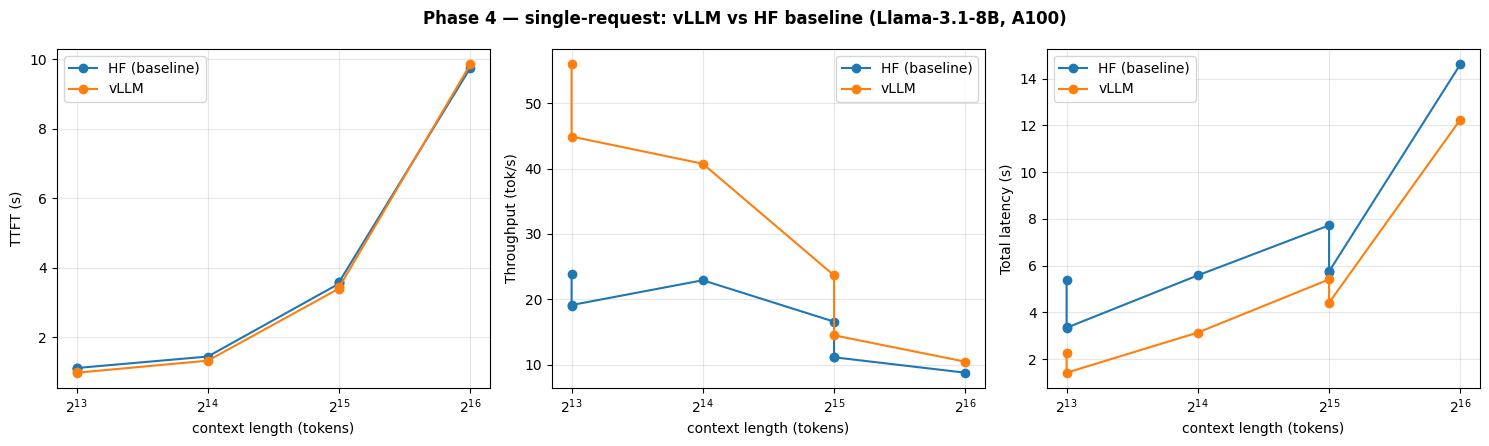

In [ ]:
# 7. TTFT vs context length, single-request (batch=1) — both backends.
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_DIR = Path('results/plots'); PLOT_DIR.mkdir(parents=True, exist_ok=True)

single = df[df.batch_size == 1].sort_values(['_backend', 'context_length'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for col, ylabel, ax in [
    ('ttft_seconds',          'TTFT (s)',                axes[0]),
    ('tokens_per_second',     'Throughput (tok/s)',      axes[1]),
    ('total_latency_seconds', 'Total latency (s)',       axes[2]),
]:
    for backend, grp in single.groupby('_backend'):
        ok = grp[grp.success == True].sort_values('context_length')
        ax.plot(ok.context_length, ok[col], marker='o', label=backend)
        fail = grp[grp.success == False]
        if len(fail):
            ax.scatter(fail.context_length, [0]*len(fail), marker='x', color='red', s=120, zorder=5, linewidths=2.5)
    ax.set_xscale('log', base=2)
    ax.set_xlabel('context length (tokens)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Phase 4 — single-request: vLLM vs HF baseline (Llama-3.1-8B, A100)', fontsize=12, fontweight='bold')
plt.tight_layout()
out = PLOT_DIR / 'phase4_single_request.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()


saved results/plots/phase4_pareto.png


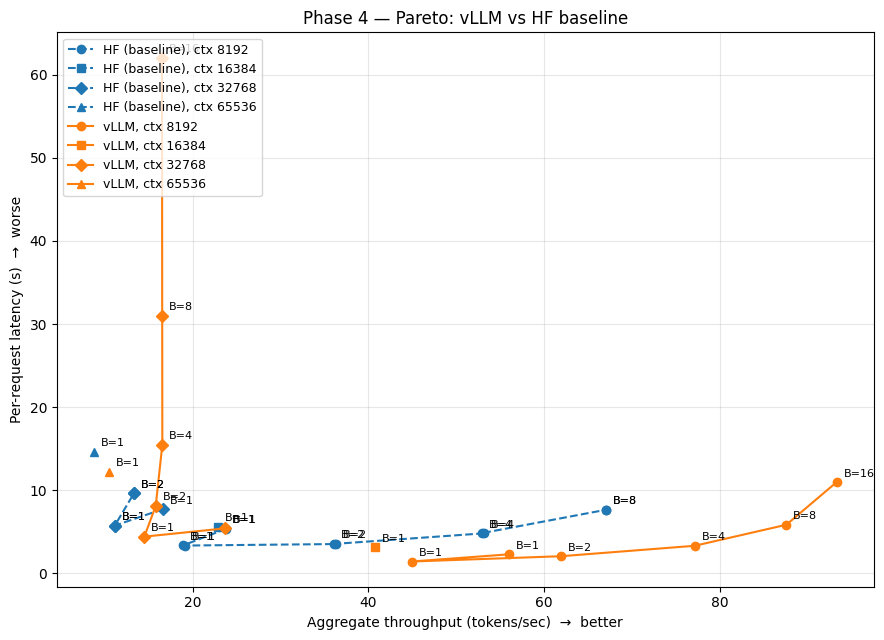

In [ ]:
# 8. Latency-vs-throughput Pareto
import matplotlib.pyplot as plt

ok = df[df.success == True].copy()
fig, ax = plt.subplots(figsize=(9, 6.5))

markers = {8192: 'o', 16384: 's', 32768: 'D', 65536: '^'}
colors  = {'HF (baseline)': '#1f77b4', 'vLLM': '#ff7f0e'}

for backend, grp_b in ok.groupby('_backend'):
    for ctx, grp_c in grp_b.groupby('context_length'):
        grp_c = grp_c.sort_values('batch_size')
        ax.plot(
            grp_c.tokens_per_second, grp_c.total_latency_seconds,
            marker=markers.get(ctx, 'o'), color=colors[backend],
            linestyle='-' if backend == 'vLLM' else '--',
            label=f'{backend}, ctx {ctx}',
        )
        for _, r in grp_c.iterrows():
            ax.annotate(f"B={int(r.batch_size)}",
                        (r.tokens_per_second, r.total_latency_seconds),
                        textcoords='offset points', xytext=(5, 4), fontsize=8)

ax.set_xlabel('Aggregate throughput (tokens/sec)  →  better')
ax.set_ylabel('Per-request latency (s)  →  worse')
ax.set_title('Phase 4 — Pareto: vLLM vs HF baseline')
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
out = Path('results/plots/phase4_pareto.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()


saved results/plots/phase4_frontier.png


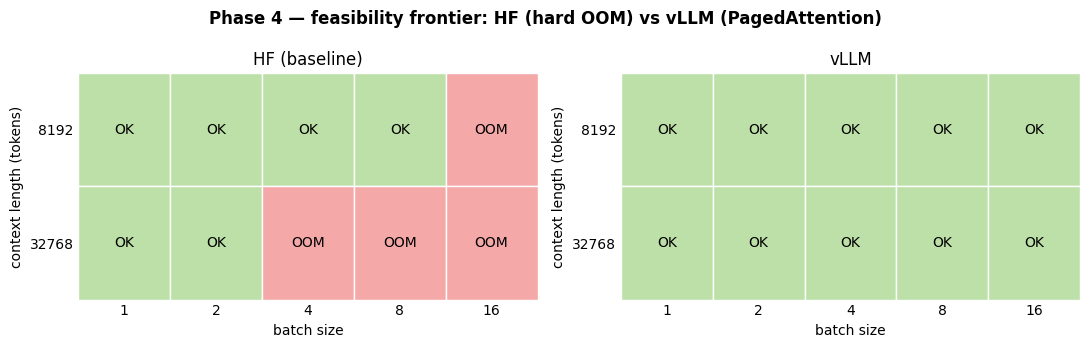

In [ ]:
# 9. Frontier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

batch_sweep = df[df.context_length.isin([8192, 32768]) & df.batch_size.isin([1, 2, 4, 8, 16])]

backends = sorted(batch_sweep['_backend'].unique())
fig, axes = plt.subplots(1, len(backends), figsize=(5.5 * len(backends), 3.5))
if len(backends) == 1:
    axes = [axes]

for ax, backend in zip(axes, backends):
    sub = batch_sweep[batch_sweep['_backend'] == backend]
    pivot = sub.pivot_table(index='context_length', columns='batch_size',
                            values='success', aggfunc='first')
    for i, ctx in enumerate(pivot.index):
        for j, bsz in enumerate(pivot.columns):
            v = pivot.loc[ctx, bsz]
            color = '#bde0a8' if v == True else ('#f4a8a8' if v == False else '#dddddd')
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white'))
            label = 'OK' if v == True else ('OOM' if v == False else '-')
            ax.text(j + 0.5, i + 0.5, label, ha='center', va='center', fontsize=10)
    ax.set_xlim(0, len(pivot.columns)); ax.set_ylim(0, len(pivot.index))
    ax.invert_yaxis()
    ax.set_xticks(np.arange(len(pivot.columns)) + 0.5); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)) + 0.5);   ax.set_yticklabels(pivot.index)
    ax.set_xlabel('batch size'); ax.set_ylabel('context length (tokens)')
    ax.set_title(backend)
    ax.tick_params(length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

fig.suptitle('Phase 4 — feasibility frontier: HF (hard OOM) vs vLLM (PagedAttention)', fontsize=12, fontweight='bold')
plt.tight_layout()
out = Path('results/plots/phase4_frontier.png')
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()